# Implementation of MCP Neuron for AND and OR Function.

This notebook completes Worksheet 3: MCP neuron, perceptron for 0 vs 1 classification, and perceptron for 3 vs 5 classification.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)

  summed_inputs = []
  state_neuron = []

  for x1, x2 in zip(X1, X2):
      summed_inputs.append(x1 + x2)

  for value in summed_inputs:
      if value >= T:
          state_neuron.append(1)
      else:
          state_neuron.append(0)

  return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    summed_inputs = []
    state_neuron = []

    for x1, x2 in zip(X1, X2):
        summed_inputs.append(x1 + x2)

    for value in summed_inputs:
        if value >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


## Answers for Task 1

**Question 1: Limitations of MCP neurons**
- MCP neurons use fixed, hand-crafted rules and thresholds, so they do not learn from data.
- They are very simple and only work well for linearly separable logic.
- A single MCP neuron cannot solve non-linearly separable problems such as XOR.
- They usually produce only binary outputs (0 or 1), so they cannot represent more complex outputs.
- They are not suitable for complex pattern recognition tasks such as image classification on their own.

**Question 2: Can XOR be solved using one MCP neuron?**
A single MCP neuron cannot solve XOR because XOR is not linearly separable.  
However, using simple if-else rules, XOR can be written as:

- if `X1 != X2`, output `1`
- else, output `0`

So XOR logic can be written manually with rules, but not solved by a single MCP threshold unit.


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mount Google Drive automatically when running in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

# Load the dataset
dataset_path_0_1 = "/content/drive/MyDrive/AI ML/DATA/mnist_0_and_1.csv"
df_0_1 = pd.read_csv(dataset_path_0_1)

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("0 vs 1 dataset path:", dataset_path_0_1)
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Unique labels:", np.unique(y))


Mounted at /content/drive
0 vs 1 dataset path: /content/drive/MyDrive/AI ML/DATA/mnist_0_and_1.csv
Feature matrix shape: (12665, 784)
Label vector shape: (12665,)
Unique labels: [0 1]


### Answers for Dataset Loading Questions

**Question 1: What does the shape of X represent?**  
The shape of `X` shows the size of the feature matrix in the form `(number_of_samples, number_of_features)`.

**Question 2: What does the shape of y represent?**  
The shape of `y` shows the size of the label vector. It contains one class label for each image in `X`.


### Viewing the Dataset.

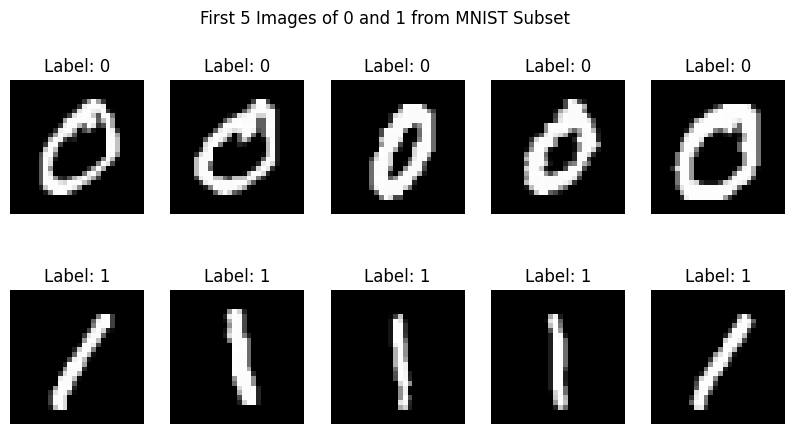

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

### Answers for Weight Initialization Questions

**Question 3: What does the weights array represent in this context?**  
The weights array stores one learnable parameter for each pixel feature. Since each MNIST image has 784 pixels, there are 784 weights.

**Question 4: Why are we initializing the weights to zero? What effect could this have on the training process?**  
We initialize the weights to zero to start from a simple neutral point. In a perceptron, zero initialization is acceptable because the weights are updated whenever the model makes mistakes. The training process then gradually moves the decision boundary toward better classification.


## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)  # Activation function (step function)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    for epoch in range(epochs):
        errors = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred != y[i]:
                update = learning_rate * (y[i] - y_pred)
                weights = weights + update * X[i]
                bias = bias + update
                errors += 1

        if errors == 0:
            print(f"Training converged at epoch {epoch + 1}")
            break

    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all == y)
    return weights, bias, accuracy

### Answers for Perceptron Training Questions

**Question 5: What is the purpose of the line `output = np.dot(X[i], weights) + bias`?**  
It calculates the weighted sum of the input features and bias for one image. This value is then used to decide the predicted class.

**Question 6: What happens when the prediction is wrong? How are the weights and bias updated?**  
When the prediction is wrong, the perceptron updates its parameters using the error `(y - y_pred)`.  
The update rules are:

- `weights = weights + learning_rate * (y - y_pred) * X[i]`
- `bias = bias + learning_rate * (y - y_pred)`

This moves the decision boundary in a direction that helps correct the mistake.

**Question 7: Why is the final accuracy important, and what do you expect it to be?**  
Final accuracy shows how many samples were classified correctly. It helps us judge how well the perceptron learned the task. For digits 0 and 1, we usually expect a high accuracy because they are easier to separate than many other digit pairs.


## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Training converged at epoch 13
The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


### Answers for Misclassification Questions

**Question 8: What does `misclassified_idx` store, and how is it used in this code?**  
`misclassified_idx` stores the index positions of the images that were classified incorrectly. The code uses those indices to display the wrongly predicted images.

**Question 9: How do you interpret the result if the output is `All images were correctly classified!`?**  
It means the trained perceptron predicted every image in that dataset correctly, so there were no errors left to visualize.


# Task 3: Perceptron Algorithm for 3 vs 5 Classification

This section repeats the same steps for the second dataset path you provided.

In [ ]:
# Load the second dataset
dataset_path_3_5 = "/content/drive/MyDrive/AI ML/DATA/mnist_dataset.csv"
df_3_5 = pd.read_csv(dataset_path_3_5)

print("Second dataset path:", dataset_path_3_5)
print("Original shape:", df_3_5.shape)
print("Original labels:", np.unique(df_3_5["label"]))

# If the file contains more than digits 3 and 5, keep only 3 and 5
if set(np.unique(df_3_5["label"])) != {3, 5}:
    df_3_5 = df_3_5[df_3_5["label"].isin([3, 5])].copy()
    print("Filtered shape for digits 3 and 5:", df_3_5.shape)
    print("Filtered labels:", np.unique(df_3_5["label"]))

# Map labels to binary classes for the perceptron: 3 -> 0, 5 -> 1
X_35 = df_3_5.drop(columns=["label"]).values
y_35_original = df_3_5["label"].values
y_35 = np.where(y_35_original == 5, 1, 0)

print("Feature matrix shape:", X_35.shape)
print("Binary label vector shape:", y_35.shape)
print("Binary labels used by perceptron:", np.unique(y_35))

Second dataset path: /content/drive/MyDrive/AI ML/DATA/mnist_dataset.csv
Original shape: (60000, 785)
Original labels: [0 1 2 3 4 5 6 7 8 9]
Filtered shape for digits 3 and 5: (11552, 785)
Filtered labels: [3 5]
Feature matrix shape: (11552, 784)
Binary label vector shape: (11552,)
Binary labels used by perceptron: [0 1]


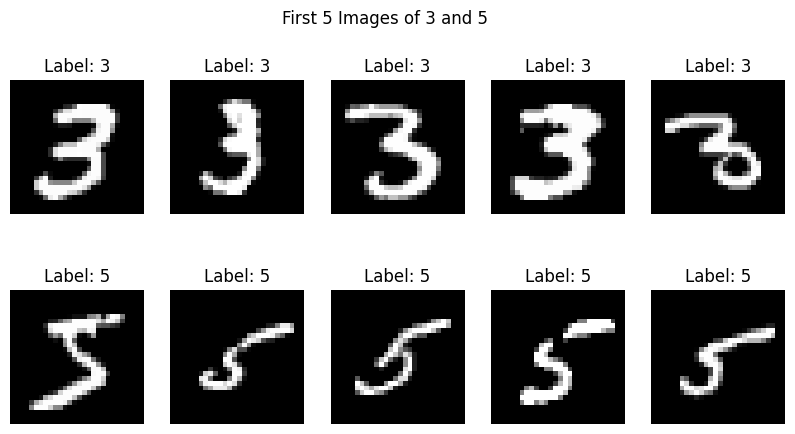

In [ ]:
# Visualize a few samples of 3 and 5
images_3 = X_35[y_35_original == 3]
images_5 = X_35[y_35_original == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_3 or images_5 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5")
    plt.show()

In [ ]:
# Initialize weights and bias for 3 vs 5
weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0

weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35, weights_35, bias_35, learning_rate=0.1, epochs=100
)

print("The Final Accuracy for 3 vs 5 is:", accuracy_35)

The Final Accuracy for 3 vs 5 is: 0.9533414127423823


Final Accuracy (3 vs 5): 0.9533


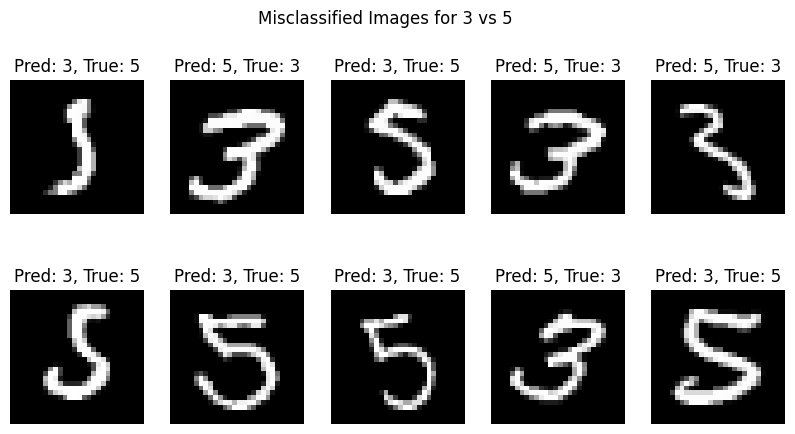

In [ ]:
# Visualize misclassified images for 3 vs 5
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

final_accuracy_35 = np.mean(y_pred_35 == y_35)
print(f"Final Accuracy (3 vs 5): {final_accuracy_35:.4f}")

misclassified_idx_35 = np.where(y_pred_35 != y_35)[0]

if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        predicted_label = 5 if y_pred_35[idx] == 1 else 3
        true_label = y_35_original[idx]
        ax.set_title(f"Pred: {predicted_label}, True: {true_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images for 3 vs 5")
    plt.show()
else:
    print("All 3 vs 5 images were correctly classified!")

## Conclusion for Task 3

The perceptron can classify digits 3 and 5, but this task is usually harder than 0 vs 1 because the handwritten shapes of 3 and 5 can look similar. Because of that, the model may produce more misclassified samples. This shows that a simple perceptron works best when the classes are more clearly linearly separable.
